In [1]:
import os
import sys

# 현재 작업 디렉토리 확인해보고
print("CWD:", os.getcwd())

# notebooks/ 에서 한 단계 위(프로젝트 루트)로 올라가기
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("PROJECT_ROOT:", PROJECT_ROOT)

# sys.path 에 프로젝트 루트가 없으면 추가
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print("Added to sys.path")


CWD: c:\Users\user\Desktop\project\scalp-vision-agent\notebooks
PROJECT_ROOT: c:\Users\user\Desktop\project\scalp-vision-agent
Added to sys.path


In [ ]:
import torch
from torch.utils.data import DataLoader
from torch import optim

from src.config import MASTER_INDEX_CSV
from src.cnn.dataset import ScalpDataset
from src.cnn.models import MultiHeadResNet18
from src.cnn.utils import labels_dict_to_tensor
from src.cnn.losses import multihead_ce_loss
from src.cnn.train import get_device, train_one_epoch, evaluate_one_epoch, train_model


In [3]:
device = get_device()
device


device(type='cuda')

In [4]:
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4


In [5]:
from torchvision import transforms as T

# 학습용 transform
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])

# 검증용 transform (지금은 같게 둬도 됨)
val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
])


In [6]:
from torch.utils.data import Subset

train_dataset = ScalpDataset(index_csv=MASTER_INDEX_CSV, split="train", transforms=train_transform)
val_dataset   = ScalpDataset(index_csv=MASTER_INDEX_CSV, split="val",   transforms=val_transform)

print(len(train_dataset), len(val_dataset))


67588 23568


In [10]:
USE_SUBSET = False   # overfit 테스트: True, 전체 학습: False

if USE_SUBSET:
    subset_indices = list(range(100))  
    train_dataset_small = Subset(train_dataset, subset_indices)
    train_loader = DataLoader(train_dataset_small, batch_size=BATCH_SIZE, shuffle=True)
else:
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [11]:
model = MultiHeadResNet18()
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)


In [12]:
batch = next(iter(train_loader))

print("type:", type(batch["image"]))
print("shape:", batch["image"].shape)
print("dtype:", batch["image"].dtype)
print("device:", batch["image"].device)


type: <class 'torch.Tensor'>
shape: torch.Size([32, 3, 224, 224])
dtype: torch.float32
device: cpu


In [13]:
len(train_dataset), len(train_loader), len(val_dataset), len(val_loader)


(67588, 2113, 23568, 737)

In [ ]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    num_epochs=10,
    device=device,
    best_model_path="models/multihead_resnet18_best.pth",
    last_model_path="models/multihead_resnet18_last.pth",
)


[01] train_loss=0.6344, train_acc=0.7428 | val_loss=0.6231, val_acc=0.7466
[02] train_loss=0.5720, train_acc=0.7674 | val_loss=0.5839, val_acc=0.7603
[03] train_loss=0.5249, train_acc=0.7863 | val_loss=0.6691, val_acc=0.7329
[04] train_loss=0.4479, train_acc=0.8200 | val_loss=0.6846, val_acc=0.7310
[05] train_loss=0.3383, train_acc=0.8673 | val_loss=0.7958, val_acc=0.7283
[06] train_loss=0.2401, train_acc=0.9089 | val_loss=0.9636, val_acc=0.7376


KeyboardInterrupt: 

In [15]:
import matplotlib.pyplot as plt

# matplotlib 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 기준
# plt.rcParams['font.family'] = 'AppleGothic' # Mac 기준
plt.rcParams['axes.unicode_minus'] = False # 음수 부호 깨짐 방지

FileNotFoundError: [Errno 2] No such file or directory: 'docs/baseline_loss_curve.png'

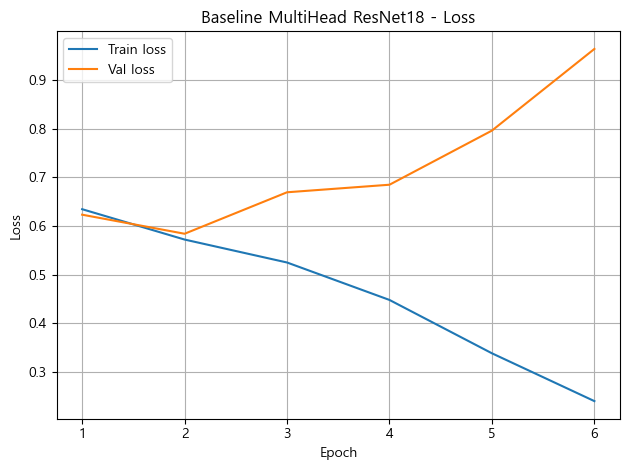

In [16]:
epochs = range(1, len(history["train_loss"]) + 1)

# 1) Loss 곡선
plt.figure()
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"],   label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline MultiHead ResNet18 - Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("docs/baseline_loss_curve.png", dpi=150)
plt.show()

# 2) Accuracy 곡선
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train acc")
plt.plot(epochs, history["val_acc"],   label="Val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline MultiHead ResNet18 - Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("docs/baseline_acc_curve.png", dpi=150)
plt.show()


In [17]:
import pandas as pd

df_hist = pd.DataFrame({
    "epoch": list(epochs),
    "train_loss": history["train_loss"],
    "train_acc":  history["train_acc"],
    "val_loss":   history["val_loss"],
    "val_acc":    history["val_acc"],
})

df_hist.to_csv("data/processed/baseline_history.csv", index=False)
df_hist.head()


OSError: Cannot save file into a non-existent directory: 'data\processed'

In [ ]:
# 모델 가중치 저장 (baseline 버전)
torch.save(
    model.state_dict(),
    "models/baseline_resnet18_multhead_epoch10.pth"
)
